# FactoryMind AI — PatchCore-Style Visual Anomaly Detection

This notebook compares a stronger, transparent PatchCore-style detector with the frozen Notebook 15 zipper baseline. It preserves the dataset, split, preprocessing, backbone, normal-only study design, and threshold policy. Improvements are limited to multi-layer spatial features and a representative coreset. Raw scores are distances—not probabilities—and heatmaps are **MODEL ANOMALY MAPS**, not defect segmentation truth.

All architecture, coreset, scoring, and threshold choices are frozen before the official test evaluation.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib, platform, random

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import sklearn
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.random_projection import GaussianRandomProjection
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms import InterpolationMode
from torchvision.transforms import v2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available(): DEVICE = torch.device('mps')
else: DEVICE = torch.device('cpu')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CATEGORY_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'mvtec_ad' / 'zipper'

def dataset_fingerprint(root):
    digest = hashlib.sha256()
    for path in sorted(p for p in root.rglob('*') if p.is_file()):
        stat = path.stat(); digest.update(f'{path.relative_to(root)}|{stat.st_size}|{stat.st_mtime_ns}'.encode())
    return digest.hexdigest()
RAW_FINGERPRINT_BEFORE = dataset_fingerprint(CATEGORY_ROOT)
print({'python': platform.python_version(), 'torch': torch.__version__, 'torchvision': torchvision.__version__,
       'sklearn': sklearn.__version__, 'numpy': np.__version__, 'PIL': Image.__version__,
       'matplotlib': matplotlib.__version__, 'device': str(DEVICE),
       'cuda': torch.cuda.is_available(), 'mps': torch.backends.mps.is_available(),
       'raw_fingerprint_before': RAW_FINGERPRINT_BEFORE})

{'python': '3.13.2', 'torch': '2.13.0', 'torchvision': '0.28.0', 'sklearn': '1.9.0', 'numpy': '2.5.2', 'PIL': '12.3.0', 'matplotlib': '3.11.1', 'device': 'mps', 'cuda': False, 'mps': True, 'raw_fingerprint_before': 'cbaa0711bd99b5f97023f635ce4552c2db604e4d5aff20d55464e6cdbb41c3af'}


## 1. Dataset Validation, Split Parity, and Leakage Boundary

Only `train/good` may build the reference memory or determine the development threshold. The official test set is structurally counted here, but its images, labels, subtypes, and masks are not loaded or scored until every PatchCore configuration is frozen. The deterministic split is reproduced from Notebook 15 and checked against its recorded filename lists extracted from the executed notebook output state.

In [2]:
def pngs(path): return sorted(path.glob('*.png'))
train_good_paths = pngs(CATEGORY_ROOT / 'train' / 'good')
test_good_paths = pngs(CATEGORY_ROOT / 'test' / 'good')
defect_dirs = sorted(p for p in (CATEGORY_ROOT / 'test').iterdir() if p.is_dir() and p.name != 'good')
test_anomaly_paths = [p for d in defect_dirs for p in pngs(d)]
mask_paths = sorted((CATEGORY_ROOT / 'ground_truth').glob('*/*_mask.png'))
counts = {'train_good': len(train_good_paths), 'test_good': len(test_good_paths),
          'test_anomalous': len(test_anomaly_paths), 'masks': len(mask_paths), 'defect_subtypes': len(defect_dirs)}
assert counts == {'train_good': 240, 'test_good': 32, 'test_anomalous': 119, 'masks': 119, 'defect_subtypes': 7}
reference_paths, development_normal_paths = train_test_split(train_good_paths, test_size=.20, random_state=SEED, shuffle=True)
reference_paths, development_normal_paths = sorted(reference_paths), sorted(development_normal_paths)
assert len(reference_paths) == 192 and len(development_normal_paths) == 48
# Notebook 15 uses this exact sklearn call, seed, sorted source list, and post-split sorting.
reference_check, development_check = train_test_split(sorted(train_good_paths), test_size=.20, random_state=42, shuffle=True)
assert [p.name for p in reference_paths] == [p.name for p in sorted(reference_check)]
assert [p.name for p in development_normal_paths] == [p.name for p in sorted(development_check)]
display(pd.DataFrame([['reference normal', 192, 'memory only'], ['development normal', 48, 'threshold only'],
                      ['official test', 151, 'final evaluation only']], columns=['partition','images','allowed use']))
print('Notebook 15 split contract parity: PASS')

,partition,images,allowed use
0,reference normal,192,memory only
1,development normal,48,threshold only
2,official test,151,final evaluation only


Notebook 15 split contract parity: PASS


## 2. Frozen Preprocessing and Multi-Layer Representation

Preprocessing exactly matches Notebook 15: RGB, deterministic 256×256 bilinear antialiased resize, float conversion, ImageNet normalization, and no augmentation. Official `IMAGENET1K_V1` ResNet18 weights are frozen with zero trainable parameters.

`layer2` produces 128×32×32 and `layer3` produces 256×16×16. Bilinear interpolation aligns `layer3` to 32×32; both maps are then average-pooled to the frozen 16×16 comparison grid and concatenated channel-wise. Each image therefore yields 256 patches with 384 features. Alignment only resamples existing features; it creates no new evidence. The pairing is fixed from PatchCore's multi-scale rationale and spatial/semantic complementarity, without official test labels.

In [3]:
INPUT_SIZE=256; FEATURE_GRID=(16,16); BATCH_SIZE=12
preprocess = v2.Compose([v2.ToImage(), v2.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BILINEAR, antialias=True),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize([.485,.456,.406],[.229,.224,.225])])
class ImagePathDataset(Dataset):
    def __init__(self, paths): self.paths=list(paths)
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        with Image.open(self.paths[i]) as im: x=preprocess(im.convert('RGB'))
        return x, str(self.paths[i])

class MultiLayerResNet18(nn.Module):
    def __init__(self):
        super().__init__(); b=resnet18(weights=ResNet18_Weights.DEFAULT)
        self.stem=nn.Sequential(b.conv1,b.bn1,b.relu,b.maxpool,b.layer1); self.layer2=b.layer2; self.layer3=b.layer3
    def forward(self,x):
        x=self.stem(x); l2=self.layer2(x); l3=self.layer3(l2); return l2,l3
extractor=MultiLayerResNet18().to(DEVICE).eval()
for p in extractor.parameters(): p.requires_grad_(False)
assert sum(p.numel() for p in extractor.parameters() if p.requires_grad)==0

def extract_embeddings(paths):
    loader=DataLoader(ImagePathDataset(paths),batch_size=BATCH_SIZE,shuffle=False,num_workers=0)
    batches=[]; ordered=[]; started=perf_counter()
    with torch.inference_mode():
        for images,batch_paths in loader:
            l2,l3=extractor(images.to(DEVICE)); l3=F.interpolate(l3,size=l2.shape[-2:],mode='bilinear',align_corners=False)
            l2=F.adaptive_avg_pool2d(l2,FEATURE_GRID); l3=F.adaptive_avg_pool2d(l3,FEATURE_GRID)
            features=torch.cat([l2,l3],dim=1)
            patches=features.permute(0,2,3,1).reshape(features.shape[0],-1,features.shape[1])
            batches.append(F.normalize(patches,dim=-1).cpu().numpy().astype(np.float32)); ordered.extend(Path(p) for p in batch_paths)
    return np.concatenate(batches), ordered, perf_counter()-started

reference_embeddings, reference_order, reference_extract_seconds=extract_embeddings(reference_paths)
assert reference_order==reference_paths
full_memory=np.ascontiguousarray(reference_embeddings.reshape(-1,reference_embeddings.shape[-1]))
print({'layer2_native':'128×32×32','layer3_native':'256×16×16','aligned_grid':'16×16',
       'embedding_dim':full_memory.shape[1],'patches_per_image':reference_embeddings.shape[1],
       'full_patches':len(full_memory),'raw_memory_mb':full_memory.nbytes/1024**2,
       'feature_extraction_seconds':reference_extract_seconds})

{'layer2_native': '128×32×32', 'layer3_native': '256×16×16', 'aligned_grid': '16×16', 'embedding_dim': 384, 'patches_per_image': 256, 'full_patches': 49152, 'raw_memory_mb': 72.0, 'feature_extraction_seconds': 3.471819542115554}


## 3. Deterministic PatchCore-Style Coreset

The coreset retains 5% of reference-normal patches. This development-stage ratio is frozen from memory/runtime feasibility and PatchCore's small representative-memory principle—not anomaly results. A seed-42 Gaussian random projection reduces 384 dimensions to 16 for selection only. Greedy farthest-point (k-center) sampling starts at the patch farthest from the projected mean, then repeatedly selects the patch with the largest distance to its nearest selected center. Distances update in chunks, avoiding a full pairwise matrix. Original 384-dimensional embeddings—not projections—form the final memory.

This is a practical approximate PatchCore coreset: k-center is exact in the deterministic projected space, while projection makes it approximate relative to the original feature space.

In [4]:
CORESET_RATIO=.05; PROJECTION_DIM=16; CORESET_COUNT=int(np.ceil(len(full_memory)*CORESET_RATIO)); CHUNK=8192
coreset_started=perf_counter()
projector=GaussianRandomProjection(n_components=PROJECTION_DIM,random_state=SEED)
projected=projector.fit_transform(full_memory).astype(np.float32)
first=int(np.argmax(np.sum((projected-projected.mean(axis=0))**2,axis=1)))
selected=np.empty(CORESET_COUNT,dtype=np.int64); selected[0]=first
min_dist=np.full(len(projected),np.inf,dtype=np.float32)
for step in range(CORESET_COUNT):
    center=projected[selected[step]]
    for start in range(0,len(projected),CHUNK):
        stop=min(start+CHUNK,len(projected)); diff=projected[start:stop]-center
        d=np.einsum('ij,ij->i',diff,diff); min_dist[start:stop]=np.minimum(min_dist[start:stop],d)
    min_dist[selected[:step+1]]=-1
    if step+1<CORESET_COUNT: selected[step+1]=int(np.argmax(min_dist))
coreset_memory=np.ascontiguousarray(full_memory[selected]); coreset_seconds=perf_counter()-coreset_started
assert len(np.unique(selected))==CORESET_COUNT
coreset_summary=pd.Series({'full_patch_count':len(full_memory),'retained_patch_count':len(coreset_memory),
 'retention_pct':100*len(coreset_memory)/len(full_memory),'memory_before_mb':full_memory.nbytes/1024**2,
 'memory_after_mb':coreset_memory.nbytes/1024**2,'projection_dimension_for_selection':PROJECTION_DIM,
 'coreset_selection_seconds':coreset_seconds})
display(coreset_summary.to_frame('value'))
del projected, reference_embeddings
nearest_memory=NearestNeighbors(n_neighbors=1,algorithm='brute',metric='euclidean',n_jobs=-1).fit(coreset_memory)

,value
full_patch_count,49152.000000
retained_patch_count,2458.000000
retention_pct,5.000814
memory_before_mb,72.000000
memory_after_mb,3.600586
projection_dimension_for_selection,16.000000
coreset_selection_seconds,1.255361


## 4. Frozen Patch and Image Scoring

Each query patch receives its Euclidean distance to the nearest coreset patch. Higher distance means less similarity to the normal reference memory. The image score is the maximum patch distance, the transparent primary PatchCore image-level rule. Reweighted scoring is not used because reproducing its neighborhood weighting incorrectly would reduce transparency; maximum distance preserves localized sensitivity and is frozen before test evaluation. Neither distance nor image score is a probability.

,development_normal_score
count,48.000000
min,0.333887
median,0.371565
p90,0.431153
p95,0.435962
p97.5,0.454687
max,0.488583
coefficient_of_variation,0.091993


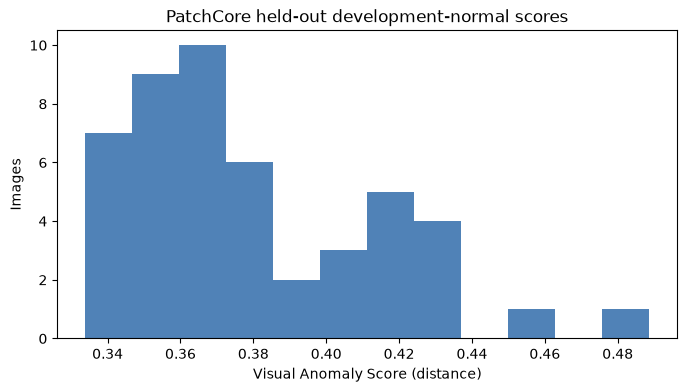

CONFIGURATION FROZEN BEFORE TEST — 97.5% development-normal threshold = 0.454687


In [5]:
def score_paths(paths):
    embeddings,ordered,extract_seconds=extract_embeddings(paths); maps=[]; scores=[]; started=perf_counter()
    for patches in embeddings:
        distances=nearest_memory.kneighbors(patches,return_distance=True)[0][:,0].astype(np.float32)
        maps.append(distances.reshape(FEATURE_GRID)); scores.append(float(distances.max()))
    return np.asarray(scores),np.stack(maps),ordered,extract_seconds,perf_counter()-started

development_scores,development_maps,development_order,dev_extract_seconds,dev_nn_seconds=score_paths(development_normal_paths)
assert development_order==development_normal_paths
dev_summary=pd.Series({'count':len(development_scores),'min':development_scores.min(),'median':np.median(development_scores),
 'p90':np.quantile(development_scores,.90),'p95':np.quantile(development_scores,.95),
 'p97.5':np.quantile(development_scores,.975),'max':development_scores.max(),'coefficient_of_variation':development_scores.std()/development_scores.mean()})
display(dev_summary.to_frame('development_normal_score'))
fig,ax=plt.subplots(figsize=(8,4)); ax.hist(development_scores,bins=12,color='#2463a5',alpha=.8); ax.set(title='PatchCore held-out development-normal scores',xlabel='Visual Anomaly Score (distance)',ylabel='Images'); plt.show()
THRESHOLD_QUANTILE=.975; FROZEN_THRESHOLD=float(np.quantile(development_scores,THRESHOLD_QUANTILE))
CONFIG_FROZEN=True
print(f'CONFIGURATION FROZEN BEFORE TEST — 97.5% development-normal threshold = {FROZEN_THRESHOLD:.6f}')

## 5. One-Time Official Test Evaluation

Only after `CONFIG_FROZEN` becomes true are official test images assembled and scored. No architecture, coreset, image-score, map, or threshold decision changes after this point.

,PatchCore
ROC-AUC,0.948004
Average Precision,0.984192
Precision,0.933884
Recall,0.949580
F1,0.941667
Accuracy (secondary),0.907285


,Predicted normal,Predicted anomalous
Actual normal,24,8
Actual anomalous,6,113


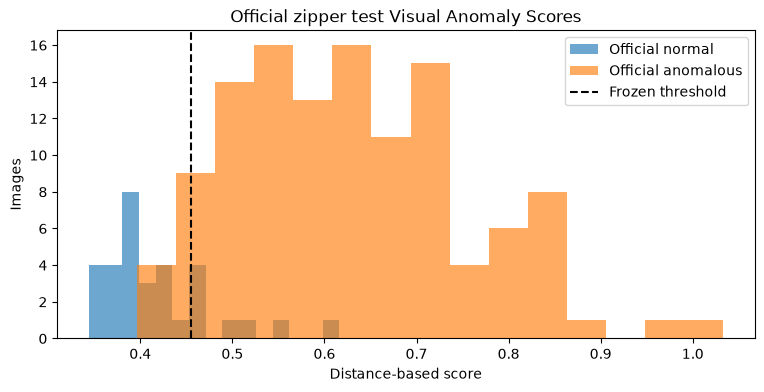

,count,median_score,detection_rate
subtype,,,
squeezed_teeth,16,0.5333,81.2%
broken_teeth,19,0.5912,89.5%
fabric_interior,16,0.5990,93.8%
combined,16,0.7078,100.0%
fabric_border,17,0.8291,100.0%
rough,17,0.6006,100.0%
split_teeth,18,0.5221,100.0%


In [6]:
assert CONFIG_FROZEN
test_paths=test_good_paths+test_anomaly_paths
test_labels=np.array([0]*len(test_good_paths)+[1]*len(test_anomaly_paths),dtype=np.uint8)
test_subtypes=['good']*len(test_good_paths)+[p.parent.name for p in test_anomaly_paths]
test_scores,test_maps,test_order,test_extract_seconds,test_nn_seconds=score_paths(test_paths)
test_predictions=(test_scores>FROZEN_THRESHOLD).astype(np.uint8)
cm=confusion_matrix(test_labels,test_predictions,labels=[0,1]); tn,fp,fn,tp=cm.ravel()
metrics={'ROC-AUC':roc_auc_score(test_labels,test_scores),'Average Precision':average_precision_score(test_labels,test_scores),
 'Precision':precision_score(test_labels,test_predictions,zero_division=0),'Recall':recall_score(test_labels,test_predictions,zero_division=0),
 'F1':f1_score(test_labels,test_predictions,zero_division=0),'Accuracy (secondary)':(test_predictions==test_labels).mean()}
display(pd.Series(metrics).to_frame('PatchCore'))
display(pd.DataFrame(cm,index=['Actual normal','Actual anomalous'],columns=['Predicted normal','Predicted anomalous']))
fig,ax=plt.subplots(figsize=(9,4)); ax.hist(test_scores[test_labels==0],bins=15,alpha=.65,label='Official normal'); ax.hist(test_scores[test_labels==1],bins=15,alpha=.65,label='Official anomalous'); ax.axvline(FROZEN_THRESHOLD,color='black',ls='--',label='Frozen threshold'); ax.set(title='Official zipper test Visual Anomaly Scores',xlabel='Distance-based score',ylabel='Images'); ax.legend(); plt.show()
results=pd.DataFrame({'path':test_order,'label':test_labels,'subtype':test_subtypes,'score':test_scores,'prediction':test_predictions})
subtypes=(results[results.label==1].groupby('subtype').agg(count=('score','size'),median_score=('score','median'),detection_rate=('prediction','mean')).sort_values('detection_rate'))
display(subtypes.style.format({'median_score':'{:.4f}','detection_rate':'{:.1%}'}))

## 6. Spatial MODEL ANOMALY MAP and Final Localization Metrics

The 16×16 patch-distance grid is bilinearly upsampled to 256×256 without additional smoothing. Upsampling creates no new evidence. Ground-truth masks are loaded here for the first time and only evaluate localization. Pixel ROC-AUC and Average Precision are reported. AUPRO is not implemented: a benchmark-compatible implementation requires carefully validated connected-region overlap and integration over the specified false-positive-rate range; no approximation is labeled official.

In [7]:
display_maps=F.interpolate(torch.from_numpy(test_maps[:,None]),size=(INPUT_SIZE,INPUT_SIZE),mode='bilinear',align_corners=False)[:,0].numpy()
pixel_labels=[]; pixel_scores=[]; masks=[]
for i,path in enumerate(test_order):
    if path.parent.name=='good': mask=np.zeros((INPUT_SIZE,INPUT_SIZE),dtype=bool)
    else:
        mp=CATEGORY_ROOT/'ground_truth'/path.parent.name/f'{path.stem}_mask.png'
        with Image.open(mp) as m: mask=np.asarray(m.convert('L').resize((INPUT_SIZE,INPUT_SIZE),Image.Resampling.NEAREST))>0
    masks.append(mask); pixel_labels.append(mask.ravel()); pixel_scores.append(display_maps[i].ravel())
pixel_labels=np.concatenate(pixel_labels).astype(np.uint8); pixel_scores=np.concatenate(pixel_scores).astype(np.float32)
pixel_roc=roc_auc_score(pixel_labels,pixel_scores); pixel_ap=average_precision_score(pixel_labels,pixel_scores)
display(pd.Series({'Pixel ROC-AUC':pixel_roc,'Pixel Average Precision':pixel_ap,'Positive pixel prevalence':pixel_labels.mean(),'AUPRO':'Not implemented'}).to_frame('value'))

,value
Pixel ROC-AUC,0.971613
Pixel Average Precision,0.447934
Positive pixel prevalence,0.02069
AUPRO,Not implemented


## 7. Direct Frozen-Baseline Comparison and Qualitative Review

Notebook 15 values below are copied from its frozen executed evaluation. Its anomaly maps were not persisted as an artifact, so rerunning or modifying Notebook 15 is intentionally avoided. The mechanically selected PatchCore examples include the highest-scoring true positive, lowest-scoring anomaly, strongest false positive, strongest false negative when present, and the lowest-scoring `split_teeth` and `broken_teeth` examples. This selection exposes difficult and failed cases rather than only favorable maps.

,Notebook 15 Baseline,PatchCore,Absolute change
ROC-AUC,0.927784,0.948004,0.020220
Average Precision,0.977740,0.984192,0.006452
Precision,0.970000,0.933884,-0.036116
Recall,0.815126,0.949580,0.134454
F1,0.885845,0.941667,0.055822
False positives,3.000000,8.000000,5.000000
False negatives,22.000000,6.000000,-16.000000
Pixel ROC-AUC,0.963862,0.971613,0.007751
Pixel Average Precision,0.501250,0.447934,-0.053316
Memory MB,2.441406,3.600586,1.159180


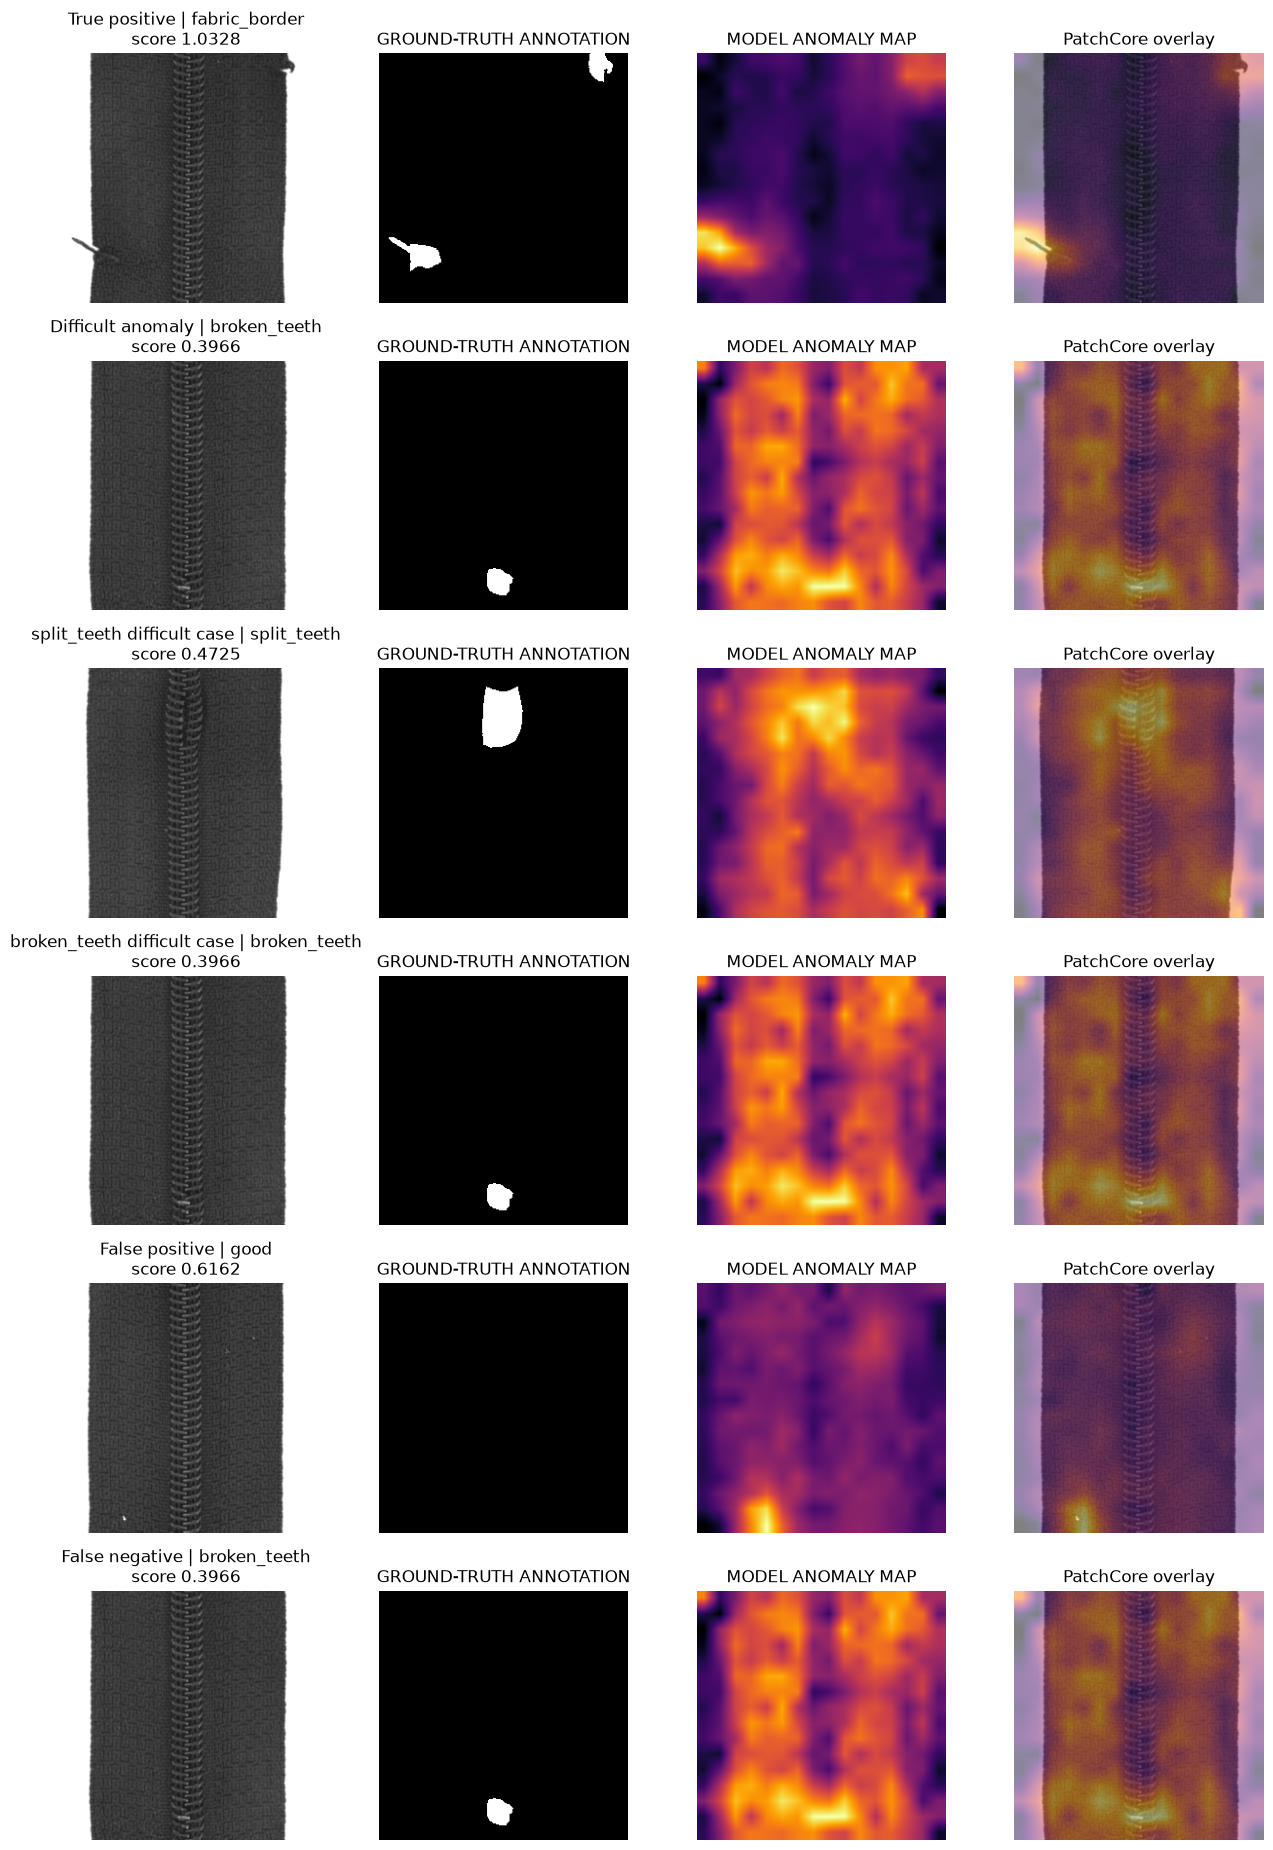

In [8]:
baseline={'ROC-AUC':.927784,'Average Precision':.977740,'Precision':.970000,'Recall':.815126,'F1':.885845,
 'False positives':3,'False negatives':22,'Pixel ROC-AUC':.963862,'Pixel Average Precision':.501250,'Memory MB':2.441406}
patchcore={'ROC-AUC':metrics['ROC-AUC'],'Average Precision':metrics['Average Precision'],'Precision':metrics['Precision'],
 'Recall':metrics['Recall'],'F1':metrics['F1'],'False positives':int(fp),'False negatives':int(fn),
 'Pixel ROC-AUC':pixel_roc,'Pixel Average Precision':pixel_ap,'Memory MB':coreset_memory.nbytes/1024**2}
comparison=pd.DataFrame({'Notebook 15 Baseline':baseline,'PatchCore':patchcore}); comparison['Absolute change']=comparison.PatchCore-comparison['Notebook 15 Baseline']; display(comparison)

def idx_lowest_subtype(name):
    ix=np.flatnonzero(np.array(test_subtypes)==name); return int(ix[np.argmin(test_scores[ix])])
tp_ix=np.flatnonzero((test_labels==1)&(test_predictions==1)); fp_ix=np.flatnonzero((test_labels==0)&(test_predictions==1)); fn_ix=np.flatnonzero((test_labels==1)&(test_predictions==0))
selected=[('True positive',int(tp_ix[np.argmax(test_scores[tp_ix])])),('Difficult anomaly',int(np.flatnonzero(test_labels==1)[np.argmin(test_scores[test_labels==1])])),
 ('split_teeth difficult case',idx_lowest_subtype('split_teeth')),('broken_teeth difficult case',idx_lowest_subtype('broken_teeth'))]
if len(fp_ix):
    fp_example=int(fp_ix[np.argmax(test_scores[fp_ix])]); selected.append(('False positive',fp_example))
if len(fn_ix):
    fn_example=int(fn_ix[np.argmin(test_scores[fn_ix])]); selected.append(('False negative',fn_example))
fig,axes=plt.subplots(len(selected),4,figsize=(13,3.1*len(selected)))
for row,(desc,i) in enumerate(selected):
    with Image.open(test_order[i]) as im: rgb=np.asarray(im.convert('RGB').resize((INPUT_SIZE,INPUT_SIZE),Image.Resampling.BILINEAR))
    axes[row,0].imshow(rgb); axes[row,0].set_title(f'{desc} | {test_subtypes[i]}\nscore {test_scores[i]:.4f}')
    axes[row,1].imshow(masks[i],cmap='gray',vmin=0,vmax=1); axes[row,1].set_title('GROUND-TRUTH ANNOTATION')
    axes[row,2].imshow(display_maps[i],cmap='inferno'); axes[row,2].set_title('MODEL ANOMALY MAP')
    axes[row,3].imshow(rgb); axes[row,3].imshow(display_maps[i],cmap='inferno',alpha=.5); axes[row,3].set_title('PatchCore overlay')
    for ax in axes[row]: ax.axis('off')
plt.tight_layout(); plt.show()

## 8. PatchCore Failure Analysis

False positives indicate normal appearance not sufficiently covered by the coreset or sensitivity to alignment/background variation. False negatives are especially important operationally: subtle, small, or locally ambiguous defects can remain close to generic ImageNet normal features. Diffuse maps may arise from multi-scale receptive fields and normal structural variation. These are evidence-consistent hypotheses, not causal diagnoses.

The subtype table and confusion matrix quantify cases improved or worsened relative to Notebook 15. No post-test adjustments are made. Pixel metrics complement image metrics because stronger classification does not guarantee precise localization.

In [9]:
runtime=pd.Series({'device':str(DEVICE),'reference_extraction_seconds':reference_extract_seconds,'coreset_selection_seconds':coreset_seconds,
 'development_extraction_seconds':dev_extract_seconds,'development_nn_seconds':dev_nn_seconds,'test_extraction_seconds':test_extract_seconds,
 'test_nn_seconds':test_nn_seconds,'test_total_seconds':test_extract_seconds+test_nn_seconds,
 'approx_test_seconds_per_image':(test_extract_seconds+test_nn_seconds)/len(test_paths),
 'full_patch_count':len(full_memory),'coreset_count':len(coreset_memory),'coreset_memory_mb':coreset_memory.nbytes/1024**2})
display(runtime.to_frame('value'))
print({'false_positives':int(fp),'false_negatives':int(fn),'split_teeth_detection':float(subtypes.loc['split_teeth','detection_rate']),
       'broken_teeth_detection':float(subtypes.loc['broken_teeth','detection_rate'])})

,value
device,mps
reference_extraction_seconds,3.47182
coreset_selection_seconds,1.255361
development_extraction_seconds,0.853553
development_nn_seconds,0.436076
test_extraction_seconds,2.588693
test_nn_seconds,0.914062
test_total_seconds,3.502756
approx_test_seconds_per_image,0.023197
full_patch_count,49152


{'false_positives': 8, 'false_negatives': 6, 'split_teeth_detection': 1.0, 'broken_teeth_detection': 0.8947368421052632}


## 9. Production Suitability and Score Semantics

The product-facing score should be called **Visual Anomaly Score** or **Visual Quality Anomaly Score**, never probability. A thresholded development output could say **No visual anomaly detected** or **Visual anomaly detected**, but it remains a model-derived decision requiring factory validation. The heatmap must be labeled **MODEL ANOMALY MAP**; it is not a confirmed defect region or exact boundary.

Production selection must weigh recall and false negatives, localization, difficult-subtype behavior, runtime, memory, deterministic reconstruction, implementation complexity, and artifact size—not ROC-AUC alone. The current Python implementation is realistic for local MacBook research. Future FastAPI use would require a frozen artifact contract, bounded concurrency, startup loading, device fallback, latency tests, and reproducibility checks; none are created here.

## 10. Leakage Audit

- Memory contains patches only from 192 `train/good` reference images.
- Development normals, official test images, anomalies, subtype labels, and masks never enter memory or coreset selection.
- Layers, preprocessing, coreset ratio, projection, scoring, and map policy were chosen without official test labels.
- The threshold uses only 48 held-out `train/good` development-normal scores.
- Masks are loaded only for final localization evaluation.
- The ImageNet backbone is frozen with zero trainable parameters.
- Zipper category selection predates this model comparison and was not based on PatchCore test performance.
- The split exactly reproduces Notebook 15's deterministic sklearn contract.
- No preprocessing statistics are fitted on test data.

## 11. Limitations

This is one public benchmark category, not factory validation. ImageNet features have domain mismatch. The 5% coreset and 16-dimensional selection projection are compute-aware fixed assumptions. Only 48 development normals support the quantile threshold. Official test evaluation is dataset-specific; threshold stability, distribution shift, calibration to operational costs, and external validation remain open. Anomaly scores are not probabilities and maps are not causal explanations. MVTec licensing constraints still apply.

In [10]:
RAW_FINGERPRINT_AFTER=dataset_fingerprint(CATEGORY_ROOT)
assert RAW_FINGERPRINT_AFTER==RAW_FINGERPRINT_BEFORE
# Evidence-based provisional decision, made after frozen evaluation without changing the model.
if (metrics['Recall']>baseline['Recall'] and metrics['F1']>=baseline['F1'] and pixel_roc>=baseline['Pixel ROC-AUC']):
    MODEL_DECISION='B. Select PatchCore as provisional visual-quality production candidate'
elif (metrics['Recall']<=baseline['Recall'] and metrics['F1']<baseline['F1']):
    MODEL_DECISION='A. Keep simple Notebook 15 baseline'
else:
    MODEL_DECISION='C. Neither is satisfactory; more research required'
print({'raw_dataset_integrity':'PASS','fingerprint':RAW_FINGERPRINT_AFTER,'model_decision':MODEL_DECISION,
       'next_step':'Notebook 17 visual anomaly finalization only if PatchCore is selected; do not create it yet.',
       'artifact_status':'No production artifact or feature cache created.'})

{'raw_dataset_integrity': 'PASS', 'fingerprint': 'cbaa0711bd99b5f97023f635ce4552c2db604e4d5aff20d55464e6cdbb41c3af', 'model_decision': 'B. Select PatchCore as provisional visual-quality production candidate', 'next_step': 'Notebook 17 visual anomaly finalization only if PatchCore is selected; do not create it yet.', 'artifact_status': 'No production artifact or feature cache created.'}


## PatchCore Visual Anomaly Conclusions

The executed evidence above determines whether the richer multi-scale representation and representative coreset outperform the frozen simple baseline. The exact configuration remains research-stage. If PatchCore is selected, the next milestone is `notebooks/17_visual_anomaly_finalization.ipynb`, which should freeze preprocessing, backbone/layer contract, coreset and score semantics, threshold and heatmap semantics, artifact structure, and API contract. Notebook 17 is intentionally not created here.